In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [45]:
df = pd.read_csv("final_smartphone_sensor_dataset.csv")


In [46]:
print(df)

      screen_time_minutes  accelerometer_mean  gyroscope_mean  \
0                     NaN                 NaN             NaN   
1                     NaN                 NaN             NaN   
2                   194.0            9.786169        0.254396   
3                     NaN                 NaN             NaN   
4                   342.0            8.825635        3.176505   
...                   ...                 ...             ...   
1995                 19.0            6.991456       12.618614   
1996                331.0            9.199577        3.396544   
1997                314.0           16.988529        9.567833   
1998                257.0           14.446704        5.682248   
1999                  NaN                 NaN             NaN   

      touch_events_per_minute  battery_consumption_per_hour  \
0                         NaN                           NaN   
1                         NaN                           NaN   
2                        55.0 

In [47]:
print(df.ndim)

2


In [48]:
print(df.size)

44000


In [49]:
print(df.head())

   screen_time_minutes  accelerometer_mean  gyroscope_mean  \
0                  NaN                 NaN             NaN   
1                  NaN                 NaN             NaN   
2                194.0            9.786169        0.254396   
3                  NaN                 NaN             NaN   
4                342.0            8.825635        3.176505   

   touch_events_per_minute  battery_consumption_per_hour  cpu_usage_percent  \
0                      NaN                           NaN                NaN   
1                      NaN                           NaN                NaN   
2                     55.0                     28.041622               26.0   
3                      NaN                           NaN                NaN   
4                     49.0                      9.805410               28.0   

   background_apps_running  device_temperature_c  usage_class  \
0                      NaN                   NaN          NaN   
1                     

In [50]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   screen_time_minutes           1423 non-null   float64
 1   accelerometer_mean            1423 non-null   float64
 2   gyroscope_mean                1423 non-null   float64
 3   touch_events_per_minute       1423 non-null   float64
 4   battery_consumption_per_hour  1423 non-null   float64
 5   cpu_usage_percent             1423 non-null   float64
 6   background_apps_running       1423 non-null   float64
 7   device_temperature_c          1423 non-null   float64
 8   usage_class                   1423 non-null   float64
 9   overheating_flag              1423 non-null   float64
 10  cpu_usage                     577 non-null    float64
 11  battery_drain                 577 non-null    float64
 12  temperature                   577 non-null    float64
 13  mem

In [51]:
print(df.describe())

       screen_time_minutes  accelerometer_mean  gyroscope_mean  \
count          1423.000000         1423.000000     1423.000000   
mean            216.383696           10.181810        7.704714   
std             115.632209            5.874727        4.048039   
min               6.000000            0.203179        0.088796   
25%             118.500000            5.148275        4.857662   
50%             219.000000            9.911211        8.072030   
75%             314.000000           14.908993       11.074208   
max             419.000000           19.919032       14.965505   

       touch_events_per_minute  battery_consumption_per_hour  \
count              1423.000000                   1423.000000   
mean                 99.406184                     18.430755   
std                  56.162032                     10.482982   
min                   1.000000                      1.008076   
25%                  50.000000                      9.339708   
50%                 1

In [52]:
print("Checking for Missing Values")
print(df.isnull().sum())

Checking for Missing Values
screen_time_minutes              577
accelerometer_mean               577
gyroscope_mean                   577
touch_events_per_minute          577
battery_consumption_per_hour     577
cpu_usage_percent                577
background_apps_running          577
device_temperature_c             577
usage_class                      577
overheating_flag                 577
cpu_usage                       1423
battery_drain                   1423
temperature                     1423
memory_usage                    1423
screen_time                     1423
gaming_time                     1423
social_media_time               1423
Age_Group                          0
Usage_Type                         0
Health_Risk                        0
total_usage                     1423
usage_intensity                 1423
dtype: int64


In [53]:
print("Removing Duplicates")
df = df.drop_duplicates()
print(df)

Removing Duplicates
      screen_time_minutes  accelerometer_mean  gyroscope_mean  \
0                     NaN                 NaN             NaN   
1                     NaN                 NaN             NaN   
2                   194.0            9.786169        0.254396   
3                     NaN                 NaN             NaN   
4                   342.0            8.825635        3.176505   
...                   ...                 ...             ...   
1640                188.0           11.667978        8.119727   
1725                 25.0           15.394225        3.654218   
1767                 39.0            1.049551        2.258699   
1782                  NaN                 NaN             NaN   
1856                103.0           10.382256       11.411333   

      touch_events_per_minute  battery_consumption_per_hour  \
0                         NaN                           NaN   
1                         NaN                           NaN   
2         

In [54]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [55]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [56]:
print(df)

      screen_time_minutes  accelerometer_mean  gyroscope_mean  \
0              217.720539           10.269443        7.622262   
1              217.720539           10.269443        7.622262   
2              194.000000            9.786169        0.254396   
3              217.720539           10.269443        7.622262   
4              342.000000            8.825635        3.176505   
...                   ...                 ...             ...   
1640           188.000000           11.667978        8.119727   
1725            25.000000           15.394225        3.654218   
1767            39.000000            1.049551        2.258699   
1782           217.720539           10.269443        7.622262   
1856           103.000000           10.382256       11.411333   

      touch_events_per_minute  battery_consumption_per_hour  \
0                  100.279461                     18.244190   
1                  100.279461                     18.244190   
2                   55.000000 

In [57]:
# Standard Scaler

In [58]:
from sklearn.preprocessing import StandardScaler
features = df.drop(["usage_class", "overheating_flag","Age_Group","Usage_Type","Health_Risk"], axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_data = pd.DataFrame(scaled_features, columns=features.columns)
print(scaled_data)


     screen_time_minutes  accelerometer_mean  gyroscope_mean  \
0          -2.902776e-16            0.000000    5.128632e-16   
1          -2.902776e-16            0.000000    5.128632e-16   
2          -2.422635e-01           -0.099586   -2.127223e+00   
3          -2.902776e-16            0.000000    5.128632e-16   
4           1.269295e+00           -0.297519   -1.283562e+00   
..                   ...                 ...             ...   
412        -3.035429e-01            0.288190    1.436263e-01   
413        -1.968300e+00            1.056041   -1.145639e+00   
414        -1.825315e+00           -1.899903   -1.548548e+00   
415        -2.902776e-16            0.000000    5.128632e-16   
416        -1.171668e+00            0.023247    1.093967e+00   

     touch_events_per_minute  battery_consumption_per_hour  cpu_usage_percent  \
0                   0.000000                 -4.032746e-16           0.000000   
1                   0.000000                 -4.032746e-16           

In [59]:
# EDA

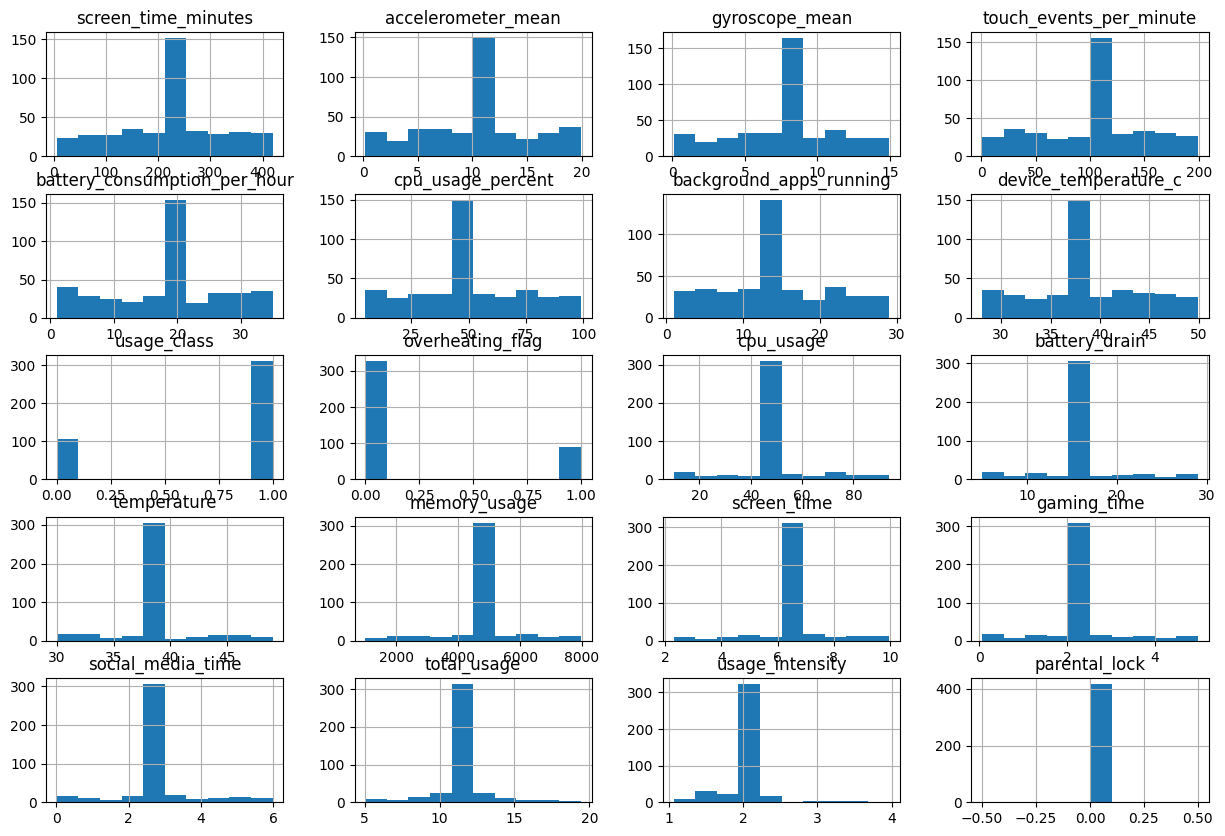

In [67]:
df.hist(figsize=(15,10))
plt.show()

In [68]:

# Outlier IQR

In [69]:

numeric_cols = df.select_dtypes(include=np.number)
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = ((numeric_cols < lower_bound) | 
                (numeric_cols > upper_bound))
print("Number of outliers using IQR:")
print(outliers_iqr.sum())

Number of outliers using IQR:
screen_time_minutes               0
accelerometer_mean                0
gyroscope_mean                   23
touch_events_per_minute           0
battery_consumption_per_hour      0
cpu_usage_percent                 0
background_apps_running           0
device_temperature_c              0
usage_class                       0
overheating_flag                 90
cpu_usage                       120
battery_drain                   120
temperature                     120
memory_usage                    120
screen_time                     120
gaming_time                     120
social_media_time               120
total_usage                     120
usage_intensity                 120
parental_lock                     0
dtype: int64


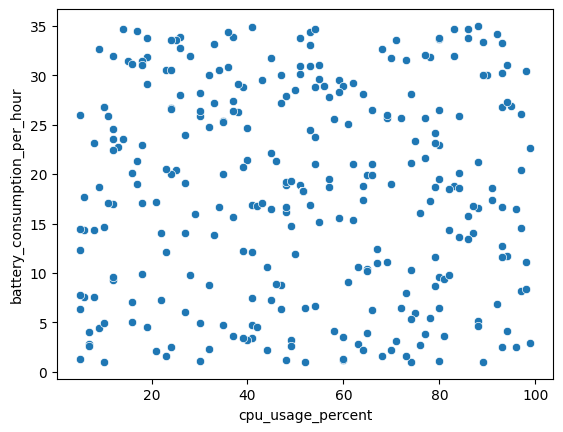

In [70]:
sns.scatterplot(x="cpu_usage_percent", 
                y="battery_consumption_per_hour", 
                data=df)
plt.show()

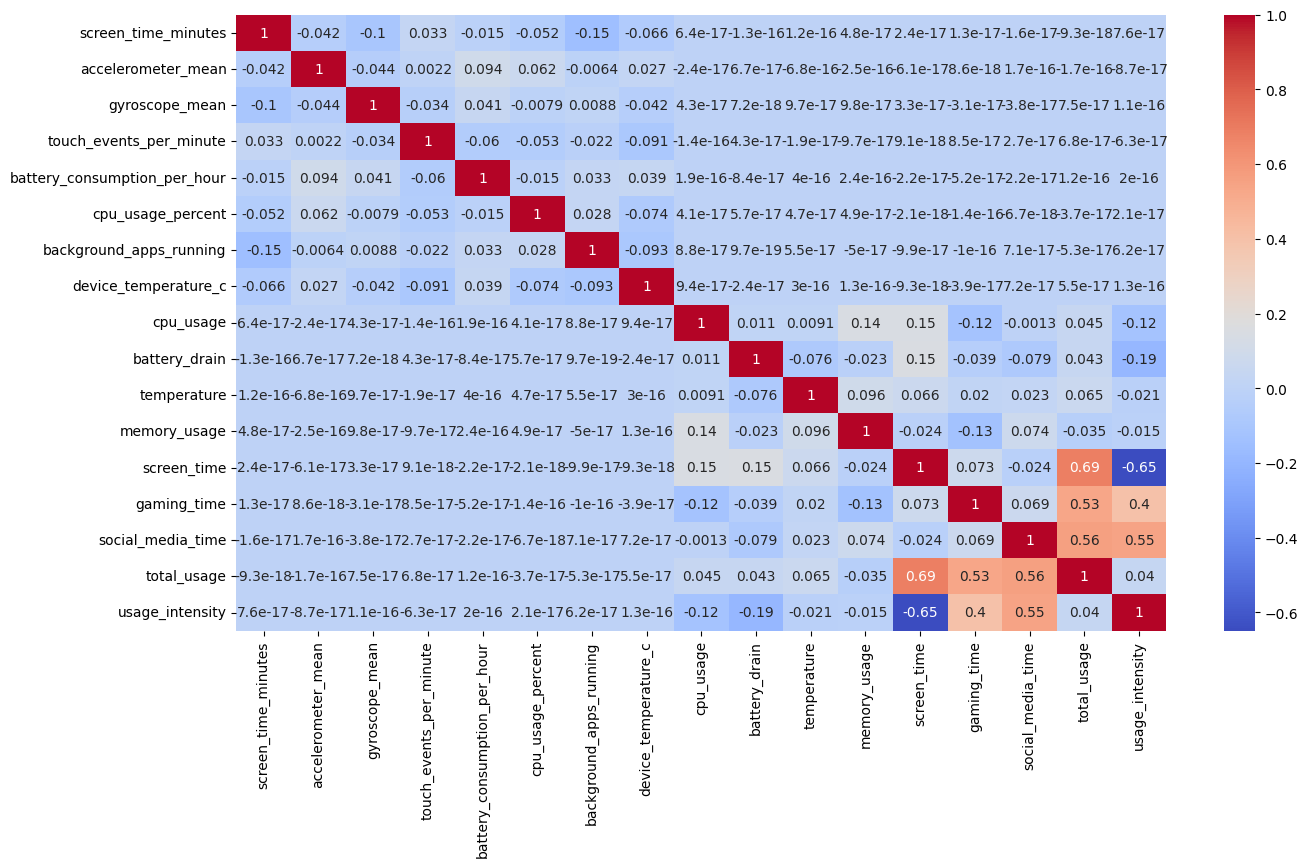

In [71]:
plt.figure(figsize=(15,8))
sns.heatmap(features.corr(), annot=True, cmap="coolwarm")
plt.show()

In [72]:
def content_type(row):
    if row["touch_events_per_minute"] > 150:
        return "Short_Videos"
    elif row["cpu_usage_percent"] > 80:
        return "Gaming"
    elif row["screen_time_minutes"] > 250:
        return "Social_Media"
    else:
        return "Educational"

df["content_type"] = df.apply(content_type, axis=1)
def disease(row):
    if row["screen_time_minutes"] > 300:
        return "Eye_Strain"
    elif row["cpu_usage_percent"] > 85 and row["touch_events_per_minute"] > 150:
        return "Addiction"
    elif row["device_temperature_c"] > 44:
        return "Fatigue"
    else:
        return "Normal"

df["disease_risk"] = df.apply(disease, axis=1)
def parental_lock(row):
    if row["Age_Group"] == "Teen" and row["screen_time_minutes"] > 240:
        return 1
    elif row["Age_Group"] == "Teen" and row["content_type"] == "Short_Videos":
        return 1
    else:
        return 0

df["parental_lock"] = df.apply(parental_lock, axis=1)


In [74]:
df

,screen_time_minutes,accelerometer_mean,gyroscope_mean,touch_events_per_minute,battery_consumption_per_hour,cpu_usage_percent,background_apps_running,device_temperature_c,usage_class,overheating_flag,...,gaming_time,social_media_time,Age_Group,Usage_Type,Health_Risk,total_usage,usage_intensity,content_type,disease_risk,parental_lock
0,217.720539,10.269443,7.622262,100.279461,18.244190,51.478114,14.377104,38.959061,1,0,...,2.74000,5.810000,Young Adult,Social Media,Medium,14.40000,2.461538,Educational,Normal,0
1,217.720539,10.269443,7.622262,100.279461,18.244190,51.478114,14.377104,38.959061,1,0,...,3.84000,5.590000,Teen,Social Media,Medium,17.36000,2.189155,Educational,Normal,0
2,194.000000,9.786169,0.254396,55.000000,28.041622,26.000000,27.000000,44.825816,0,1,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Educational,Fatigue,0
3,217.720539,10.269443,7.622262,100.279461,18.244190,51.478114,14.377104,38.959061,1,0,...,2.00000,0.020000,Teen,Productivity,High,10.44000,1.239905,Educational,Normal,0
4,342.000000,8.825635,3.176505,49.000000,9.805410,28.000000,29.000000,38.589571,1,0,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Social_Media,Eye_Strain,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,188.000000,11.667978,8.119727,173.000000,6.414355,52.000000,29.000000,28.776850,1,0,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Short_Videos,Normal,0
1725,25.000000,15.394225,3.654218,117.000000,31.089944,16.000000,28.000000,40.089650,0,0,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Educational,Normal,0
1767,39.000000,1.049551,2.258699,93.000000,25.997230,69.000000,28.000000,31.303718,0,0,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Educational,Normal,0
1782,217.720539,10.269443,7.622262,100.279461,18.244190,51.478114,14.377104,38.959061,1,0,...,1.03000,3.650000,Adult,Social Media,Low,8.38000,2.264865,Educational,Normal,0


In [75]:

df["usage_class"] = df["usage_class"].apply(lambda x: 1 if x >= 0.5 else 0)
df["overheating_flag"] = df["overheating_flag"].apply(lambda x: 1 if x >= 0.5 else 0)
df["usage_class"] = df["usage_class"].astype(int)
df["overheating_flag"] = df["overheating_flag"].astype(int)
df["usage_class"] = df["usage_class"].astype(int)
df["overheating_flag"] = df["overheating_flag"].astype(int)
X = df.drop(["usage_class", "overheating_flag", "Age_Group", "Usage_Type", "Health_Risk","content_type","disease_risk"], axis=1)
y_usage = df["usage_class"]
y_heat = df["overheating_flag"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train_usage, y_test_usage, y_train_heat, y_test_heat = train_test_split(
    X_scaled, y_usage, y_heat, test_size=0.2, random_state=42
)

In [82]:
# PCA (Dimensionality Reduction)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Reduced Features:", X_pca.shape)

Reduced Features: (417, 14)


In [83]:
df

,screen_time_minutes,accelerometer_mean,gyroscope_mean,touch_events_per_minute,battery_consumption_per_hour,cpu_usage_percent,background_apps_running,device_temperature_c,usage_class,overheating_flag,...,gaming_time,social_media_time,Age_Group,Usage_Type,Health_Risk,total_usage,usage_intensity,content_type,disease_risk,parental_lock
0,217.720539,10.269443,7.622262,100.279461,18.244190,51.478114,14.377104,38.959061,1,0,...,2.74000,5.810000,Young Adult,Social Media,Medium,14.40000,2.461538,Educational,Normal,0
1,217.720539,10.269443,7.622262,100.279461,18.244190,51.478114,14.377104,38.959061,1,0,...,3.84000,5.590000,Teen,Social Media,Medium,17.36000,2.189155,Educational,Normal,0
2,194.000000,9.786169,0.254396,55.000000,28.041622,26.000000,27.000000,44.825816,0,1,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Educational,Fatigue,0
3,217.720539,10.269443,7.622262,100.279461,18.244190,51.478114,14.377104,38.959061,1,0,...,2.00000,0.020000,Teen,Productivity,High,10.44000,1.239905,Educational,Normal,0
4,342.000000,8.825635,3.176505,49.000000,9.805410,28.000000,29.000000,38.589571,1,0,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Social_Media,Eye_Strain,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,188.000000,11.667978,8.119727,173.000000,6.414355,52.000000,29.000000,28.776850,1,0,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Short_Videos,Normal,0
1725,25.000000,15.394225,3.654218,117.000000,31.089944,16.000000,28.000000,40.089650,0,0,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Educational,Normal,0
1767,39.000000,1.049551,2.258699,93.000000,25.997230,69.000000,28.000000,31.303718,0,0,...,2.43125,2.934833,Adult,Productivity,Low,11.73725,1.967634,Educational,Normal,0
1782,217.720539,10.269443,7.622262,100.279461,18.244190,51.478114,14.377104,38.959061,1,0,...,1.03000,3.650000,Adult,Social Media,Low,8.38000,2.264865,Educational,Normal,0


In [84]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train_usage)
lr_pred = lr.predict(X_test)


In [85]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test_usage, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.73      0.73      0.73        22
           1       0.90      0.90      0.90        62

    accuracy                           0.86        84
   macro avg       0.82      0.82      0.82        84
weighted avg       0.86      0.86      0.86        84



In [86]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train_usage)

rf_pred = rf.predict(X_test)
rf_heat = RandomForestClassifier()
rf_heat.fit(X_train, y_train_heat)

heat_pred = rf_heat.predict(X_test)

print("Overheating Prediction Results")
print(classification_report(y_test_heat, heat_pred))

Overheating Prediction Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        19

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
# ENCODING
le_age = LabelEncoder()
le_usage = LabelEncoder()
le_health = LabelEncoder()
le_content = LabelEncoder()
le_disease = LabelEncoder()

df["Age_Group"] = le_age.fit_transform(df["Age_Group"])
df["Usage_Type"] = le_usage.fit_transform(df["Usage_Type"])
df["Health_Risk"] = le_health.fit_transform(df["Health_Risk"])
df["content_type"] = le_content.fit_transform(df["content_type"])
df["disease_risk"] = le_disease.fit_transform(df["disease_risk"])

In [88]:
X = df.drop([
    "usage_class",
    "overheating_flag",
    "Age_Group",
    "Usage_Type",
    "Health_Risk",
    "content_type",
    "disease_risk",
    "parental_lock"
], axis=1)

y = df[[
    "usage_class",
    "overheating_flag",
    "Age_Group",
    "Usage_Type",
    "Health_Risk",
    "content_type",
    "disease_risk",
    "parental_lock"
]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
for i, col in enumerate(y.columns):
    print("\n===== ", col, " =====")
    print(classification_report(y_test[col], y_pred[:, i]))

print("\n🔮 Sample Prediction:")
for i, col in enumerate(y.columns):
    print(col, ":", prediction[0][i])


=====  usage_class  =====
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.98      1.00      0.99        62

    accuracy                           0.99        84
   macro avg       0.99      0.98      0.98        84
weighted avg       0.99      0.99      0.99        84


=====  overheating_flag  =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        19

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


=====  Age_Group  =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        68
           1       1.00      1.00      1.00         6
           2       0.91      1.00      0.95        10

    accuracy                           0.99 

In [89]:

# Final Smart Prediction Function
def final_predict(input_data):
    input_data = np.array(input_data).reshape(1, -1)
    scaled = scaler.transform(input_data)
    reduced = pca.transform(scaled)

    usage = rf_usage.predict(reduced)[0]
    heat = rf_heat.predict(reduced)[0]

    result = {
        "Usage": "High" if usage else "Normal",
        "Overheating": "Yes" if heat else "No"
    }

    # Smart logic
    if result["Usage"] == "High":
        result["Advice"] = "Reduce screen time"
    else:
        result["Advice"] = "Normal usage"

    return result
